# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `species` using the other variables in the dataset.

**Dummify** all variables that require this.

In [2]:
! pip install palmerpenguins

In [100]:
import palmerpenguins
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import root_mean_squared_error, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib import pyplot as plt

In [11]:
penguins_df = palmerpenguins.load_penguins()
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [13]:
#drop NAs
penguins_df = penguins_df.dropna()
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Let's use the other variables to predict `species`. Prepare your data and fit the following models on the entire dataset:

* Two kNN models (for different values of K)
* Two decision tree models (for different complexities of trees)

Compute the following, for each of your models, on test data. Keep in mind that you may need to stratify your creation of the training and test data.

* Confusion matrix
* Overall Accuracy
* Precision, Recall, AUC, and F1-score for each species

Create one ROC plot for the species of your choice.

In [14]:
X = penguins_df.drop(["species"], axis = 1)
y = penguins_df["species"]

In [15]:
X.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [16]:
y.head()

,species
0,Adelie
1,Adelie
2,Adelie
4,Adelie
5,Adelie


In [18]:
#column transformer that dummifies variables
ct_dummify = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore'),
    make_column_selector(dtype_include=object))
  ],
  remainder = "passthrough"
).set_output(transform = "pandas")

ct_dummify.fit_transform(X).head()

,dummify__island_Biscoe,dummify__island_Dream,dummify__island_Torgersen,dummify__sex_female,dummify__sex_male,remainder__bill_length_mm,remainder__bill_depth_mm,remainder__flipper_length_mm,remainder__body_mass_g,remainder__year
0,0.0,0.0,1.0,0.0,1.0,39.1,18.7,181.0,3750.0,2007
1,0.0,0.0,1.0,1.0,0.0,39.5,17.4,186.0,3800.0,2007
2,0.0,0.0,1.0,1.0,0.0,40.3,18.0,195.0,3250.0,2007
4,0.0,0.0,1.0,1.0,0.0,36.7,19.3,193.0,3450.0,2007
5,0.0,0.0,1.0,0.0,1.0,39.3,20.6,190.0,3650.0,2007


In [20]:
#column transformer that standardizes variables
ct_stdz = ColumnTransformer(
  [
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
).set_output(transform = "pandas")

ct_stdz.fit_transform(X).head()

,standardize__bill_length_mm,standardize__bill_depth_mm,standardize__flipper_length_mm,standardize__body_mass_g,standardize__year,remainder__island,remainder__sex
0,-0.896042,0.780732,-1.426752,-0.568475,-1.283742,Torgersen,male
1,-0.822788,0.119584,-1.069474,-0.506286,-1.283742,Torgersen,female
2,-0.676280,0.424729,-0.426373,-1.190361,-1.283742,Torgersen,female
4,-1.335566,1.085877,-0.569284,-0.941606,-1.283742,Torgersen,female
5,-0.859415,1.747026,-0.783651,-0.692852,-1.283742,Torgersen,male


In [30]:
penguins_df['species'].value_counts(normalize = True)

,proportion
species,
Adelie,0.438438
Gentoo,0.357357
Chinstrap,0.204204


Since our dataset is imbalanced (different proportions of each species) some folds of our cross validation could end up with mostly one class, which can result in inaccurate evaluation metrics. We'll use stratified K fold to keep class balance in each train/test split.

## kNN model with k = 5

In [36]:
kNN_pipeline1 = Pipeline(
    [
        ("dummify", ct_dummify),
        ("standardize", ct_stdz),
        ("kNN", KNeighborsClassifier(n_neighbors=5))
    ]
)

In [33]:
#predict y values with cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)
y_kNN1_pred = cross_val_predict(kNN_pipeline1, X, y, cv=cv)

In [129]:
#overall accuracy and confusion matrix
accuracy_kNN1 = cross_val_score(kNN_pipeline1, X, y,
                            cv=cv, scoring="accuracy")

accuracy_kNN1.mean(), confusion_matrix(y, y_kNN1_pred)

(np.float64(0.9939393939393939),
 array([[145,   1,   0],
        [  1,  67,   0],
        [  0,   0, 119]]))

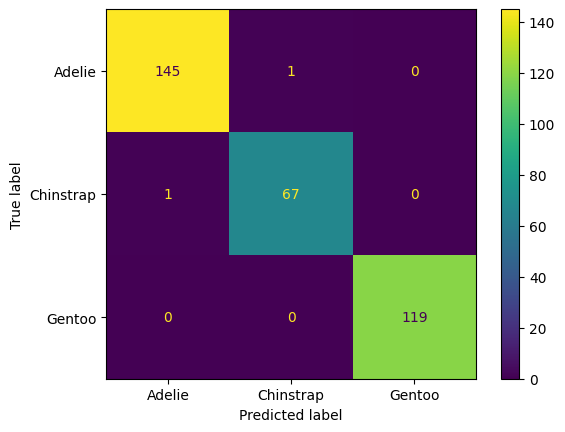

In [69]:
ConfusionMatrixDisplay.from_predictions(y, y_kNN1_pred)

In [70]:
#precision, Recall, AUC, and F1-score for Adelie species
is_Adelie = (y == "Adelie")

precision_kNN1 = cross_val_score(kNN_pipeline1, X, is_Adelie,
                cv=cv, scoring="precision").mean()

recall_kNN1 = cross_val_score(kNN_pipeline1, X, is_Adelie,
                cv=cv, scoring="recall").mean()

auc_kNN1 = cross_val_score(kNN_pipeline1, X, is_Adelie,
                cv=cv, scoring="roc_auc").mean()

f1score_kNN1 = cross_val_score(kNN_pipeline1, X, is_Adelie,
                            cv=cv, scoring="f1").mean()


precision_kNN1, recall_kNN1, auc_kNN1, f1score_kNN1

(np.float64(0.9933333333333334),
 np.float64(0.9928571428571429),
 np.float64(0.999812030075188),
 np.float64(0.9928480204342274))

In [71]:
#precision, Recall, AUC, and F1-score for Gentoo species
is_Gentoo = (y == "Gentoo")

precision_kNN1 = cross_val_score(kNN_pipeline1, X, is_Gentoo,
                cv=cv, scoring="precision").mean()

recall_kNN1 = cross_val_score(kNN_pipeline1, X, is_Gentoo,
                cv=cv, scoring="recall").mean()

auc_kNN1 = cross_val_score(kNN_pipeline1, X, is_Gentoo,
                cv=cv, scoring="roc_auc").mean()

f1score_kNN1 = cross_val_score(kNN_pipeline1, X, is_Gentoo,
                            cv=cv, scoring="f1").mean()


precision_kNN1, recall_kNN1, auc_kNN1, f1score_kNN1

(np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0))

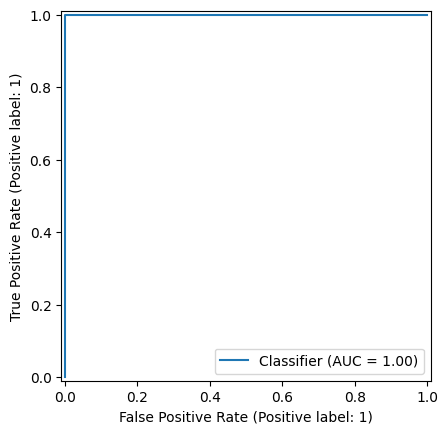

In [84]:
#ROC curve for Gentoo species with kNN = 5

#predicted probability of Gentoo species using kNN = 5 model
y_proba = cross_val_predict(kNN_pipeline1, X, is_Gentoo, cv = cv, method = "predict_proba")[:, 1]
RocCurveDisplay.from_predictions(is_Gentoo, y_proba)

Interesting, this kNN model = the optimal model.

In [72]:
#precision, Recall, AUC, and F1-score for Chinstrap species
is_Chinstrap = (y == "Chinstrap")

precision_kNN1 = cross_val_score(kNN_pipeline1, X, is_Chinstrap,
                cv=cv, scoring="precision").mean()

recall_kNN1 = cross_val_score(kNN_pipeline1, X, is_Chinstrap,
                cv=cv, scoring="recall").mean()

auc_kNN1 = cross_val_score(kNN_pipeline1, X, is_Chinstrap,
                cv=cv, scoring="roc_auc").mean()

f1score_kNN1 = cross_val_score(kNN_pipeline1, X, is_Chinstrap,
                            cv=cv, scoring="f1").mean()


precision_kNN1, recall_kNN1, auc_kNN1, f1score_kNN1

(np.float64(0.9857142857142858),
 np.float64(0.9857142857142858),
 np.float64(0.9996913580246914),
 np.float64(0.9846153846153847))

## kNN model with k = 10

In [85]:
kNN_pipeline2 = Pipeline(
    [
        ("dummify", ct_dummify),
        ("standardize", ct_stdz),
        ("kNN", KNeighborsClassifier(n_neighbors=10))
    ]
)

In [86]:
#predict y values with cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)
y_kNN2_pred = cross_val_predict(kNN_pipeline2, X, y, cv=cv)

In [130]:
#overall accuracy and confusion matrix
accuracy_kNN2 = cross_val_score(kNN_pipeline2, X, y,
                            cv=cv, scoring="accuracy")

accuracy_kNN2.mean(), confusion_matrix(y, y_kNN2_pred)

(np.float64(0.990909090909091),
 array([[145,   1,   0],
        [  2,  66,   0],
        [  0,   0, 119]]))

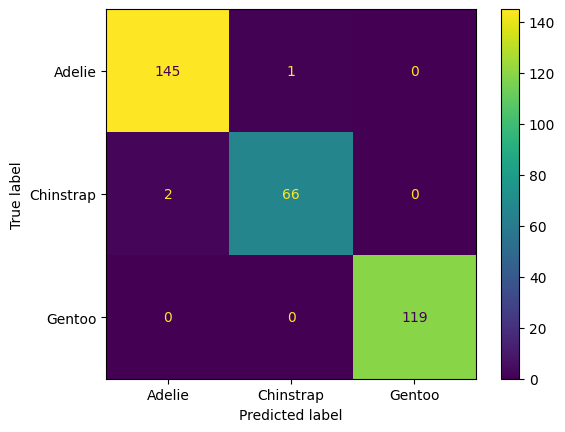

In [88]:
ConfusionMatrixDisplay.from_predictions(y, y_kNN2_pred)

In [108]:
#precision, Recall, AUC, and F1-score for Adelie species
precision_kNN2 = cross_val_score(kNN_pipeline2, X, is_Adelie,
                cv=cv, scoring="precision").mean()

recall_kNN2 = cross_val_score(kNN_pipeline2, X, is_Adelie,
                cv=cv, scoring="recall").mean()

auc_kNN2 = cross_val_score(kNN_pipeline2, X, is_Adelie,
                cv=cv, scoring="roc_auc").mean()

f1score_kNN2 = cross_val_score(kNN_pipeline2, X, is_Adelie,
                            cv=cv, scoring="f1").mean()


precision_kNN2, recall_kNN2, auc_kNN2, f1score_kNN2

(np.float64(0.9875),
 np.float64(0.993103448275862),
 np.float64(1.0),
 np.float64(0.9900396151669497))

In [109]:
#precision, Recall, AUC, and F1-score for Gentoo species
precision_kNN2 = cross_val_score(kNN_pipeline2, X, is_Gentoo,
                cv=cv, scoring="precision").mean()

recall_kNN2 = cross_val_score(kNN_pipeline2, X, is_Gentoo,
                cv=cv, scoring="recall").mean()

auc_kNN2 = cross_val_score(kNN_pipeline2, X, is_Gentoo,
                cv=cv, scoring="roc_auc").mean()

f1score_kNN2 = cross_val_score(kNN_pipeline2, X, is_Gentoo,
                            cv=cv, scoring="f1").mean()


precision_kNN2, recall_kNN2, auc_kNN2, f1score_kNN2

(np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0))

In [110]:
#precision, Recall, AUC, and F1-score for Chinstrap species
precision_kNN2 = cross_val_score(kNN_pipeline2, X, is_Chinstrap,
                cv=cv, scoring="precision").mean()

recall_kNN2 = cross_val_score(kNN_pipeline2, X, is_Chinstrap,
                cv=cv, scoring="recall").mean()

auc_kNN2 = cross_val_score(kNN_pipeline2, X, is_Chinstrap,
                cv=cv, scoring="roc_auc").mean()

f1score_kNN2 = cross_val_score(kNN_pipeline2, X, is_Chinstrap,
                            cv=cv, scoring="f1").mean()


precision_kNN2, recall_kNN2, auc_kNN2, f1score_kNN2

(np.float64(0.9846153846153847),
 np.float64(0.9703296703296704),
 np.float64(0.9995749533485382),
 np.float64(0.9772079772079773))

## Decision tree with max depth = 2

[Text(0.5, 0.8333333333333334, 'remainder__flipper_length_mm <= 206.5\ngini = 0.638\nsamples = 333\nvalue = [146, 68, 119]'),
 Text(0.25, 0.5, 'remainder__bill_length_mm <= 43.35\ngini = 0.429\nsamples = 208\nvalue = [144.0, 63.0, 1.0]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.067\nsamples = 145\nvalue = [140, 5, 0]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.148\nsamples = 63\nvalue = [4, 58, 1]'),
 Text(0.75, 0.5, 'remainder__bill_depth_mm <= 17.65\ngini = 0.107\nsamples = 125\nvalue = [2, 5, 118]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 118\nvalue = [0, 0, 118]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.408\nsamples = 7\nvalue = [2, 5, 0]')]

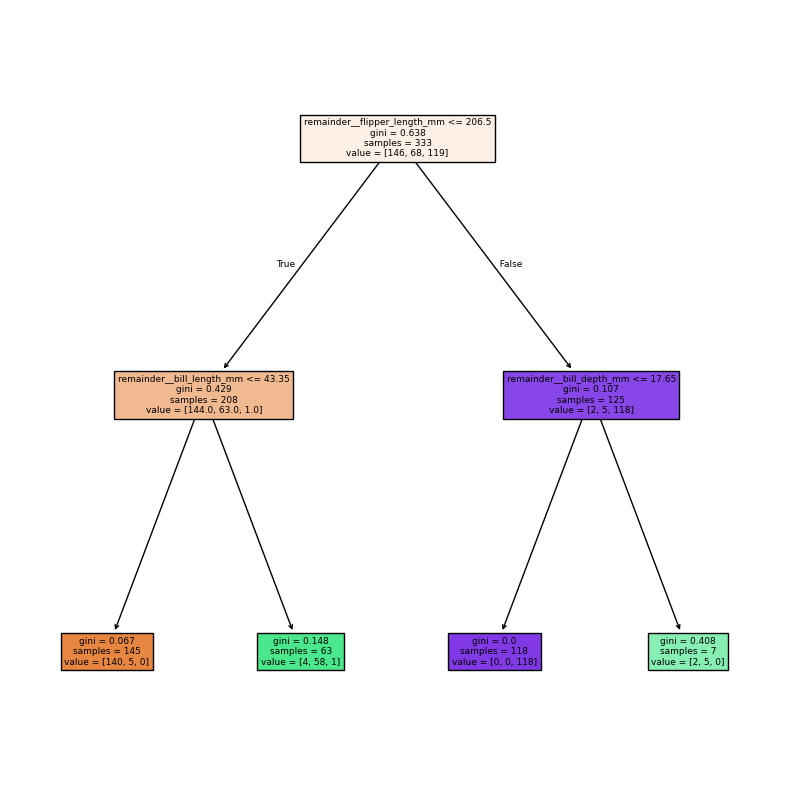

In [101]:
dt_pipeline1 = Pipeline(
  [("dummify", ct_dummify),
  ("decision_tree", DecisionTreeClassifier(max_depth=2))]
)

dt_pipeline1.fit(X=X, y=y)

# Access the Decision Tree estimator by its name in the pipeline
decision_tree_estimator = dt_pipeline1.named_steps['decision_tree']

feat_names = dt_pipeline1.named_steps["dummify"].get_feature_names_out(
    input_features=getattr(X, "columns", None)
)


# Plot the decision tree
plt.figure(figsize=(10,10))
plot_tree(decision_tree_estimator, feature_names=feat_names, filled = True)

In [103]:
print(decision_tree_estimator.classes_)

['Adelie' 'Chinstrap' 'Gentoo']


Orange = Adelie

Green = Chinstrap

Purple = Gentoo

In [104]:
#predict y values with cross validation
y_dt1_pred = cross_val_predict(dt_pipeline1, X, y, cv=cv)

In [128]:
#overall accuracy and confusion matrix
accuracy_dt1 = cross_val_score(dt_pipeline1, X, y,
                            cv=cv, scoring="accuracy")

accuracy_dt1.mean(), confusion_matrix(y, y_dt1_pred)

(np.float64(0.9397557666214382),
 array([[142,   3,   1],
        [  1,  67,   0],
        [  1,   0, 118]]))

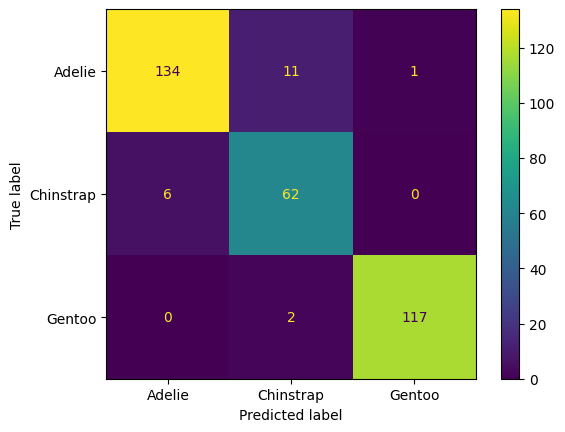

In [107]:
ConfusionMatrixDisplay.from_predictions(y, y_dt1_pred)

In [111]:
#precision, Recall, AUC, and F1-score for Adelie species
precision_dt1 = cross_val_score(dt_pipeline1, X, is_Adelie,
                cv=cv, scoring="precision").mean()

recall_dt1 = cross_val_score(dt_pipeline1, X, is_Adelie,
                cv=cv, scoring="recall").mean()

auc_dt1 = cross_val_score(dt_pipeline1, X, is_Adelie,
                cv=cv, scoring="roc_auc").mean()

f1score_dt1 = cross_val_score(dt_pipeline1, X, is_Adelie,
                            cv=cv, scoring="f1").mean()


precision_dt1, recall_dt1, auc_dt1, f1score_dt1

(np.float64(0.9732872503840244),
 np.float64(0.9588505747126437),
 np.float64(0.9725501545102272),
 np.float64(0.9691228070175437))

In [112]:
#precision, Recall, AUC, and F1-score for Gentoo species
precision_dt1 = cross_val_score(dt_pipeline1, X, is_Gentoo,
                cv=cv, scoring="precision").mean()

recall_dt1 = cross_val_score(dt_pipeline1, X, is_Gentoo,
                cv=cv, scoring="recall").mean()

auc_dt1 = cross_val_score(dt_pipeline1, X, is_Gentoo,
                cv=cv, scoring="roc_auc").mean()

f1score_dt1 = cross_val_score(dt_pipeline1, X, is_Gentoo,
                            cv=cv, scoring="f1").mean()


precision_dt1, recall_dt1, auc_dt1, f1score_dt1

(np.float64(0.992),
 np.float64(0.9916666666666668),
 np.float64(0.993452380952381),
 np.float64(0.9916630481980026))

In [113]:
#precision, Recall, AUC, and F1-score for Chinstrap species
precision_dt1 = cross_val_score(dt_pipeline1, X, is_Chinstrap,
                cv=cv, scoring="precision").mean()

recall_dt1 = cross_val_score(dt_pipeline1, X, is_Chinstrap,
                cv=cv, scoring="recall").mean()

auc_dt1 = cross_val_score(dt_pipeline1, X, is_Chinstrap,
                cv=cv, scoring="roc_auc").mean()

f1score_dt1 = cross_val_score(dt_pipeline1, X, is_Chinstrap,
                            cv=cv, scoring="f1").mean()


precision_dt1, recall_dt1, auc_dt1, f1score_dt1

(np.float64(0.975),
 np.float64(0.9846153846153847),
 np.float64(0.988534107402032),
 np.float64(0.9786666666666667))

## Decision tree with max depth = 4

[Text(0.65, 0.9, 'remainder__flipper_length_mm <= 206.5\ngini = 0.638\nsamples = 333\nvalue = [146, 68, 119]'),
 Text(0.4, 0.7, 'remainder__bill_length_mm <= 43.35\ngini = 0.429\nsamples = 208\nvalue = [144.0, 63.0, 1.0]'),
 Text(0.525, 0.8, 'True  '),
 Text(0.2, 0.5, 'remainder__bill_length_mm <= 42.35\ngini = 0.067\nsamples = 145\nvalue = [140, 5, 0]'),
 Text(0.1, 0.3, 'remainder__bill_depth_mm <= 16.65\ngini = 0.015\nsamples = 134\nvalue = [133, 1, 0]'),
 Text(0.05, 0.1, 'gini = 0.165\nsamples = 11\nvalue = [10, 1, 0]'),
 Text(0.15, 0.1, 'gini = 0.0\nsamples = 123\nvalue = [123, 0, 0]'),
 Text(0.3, 0.3, 'remainder__flipper_length_mm <= 189.5\ngini = 0.463\nsamples = 11\nvalue = [7, 4, 0]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4, 0]'),
 Text(0.35, 0.1, 'gini = 0.0\nsamples = 7\nvalue = [7, 0, 0]'),
 Text(0.6, 0.5, 'dummify__island_Dream <= 0.5\ngini = 0.148\nsamples = 63\nvalue = [4, 58, 1]'),
 Text(0.5, 0.3, 'remainder__bill_length_mm <= 47.2\ngini = 0.375\nsample

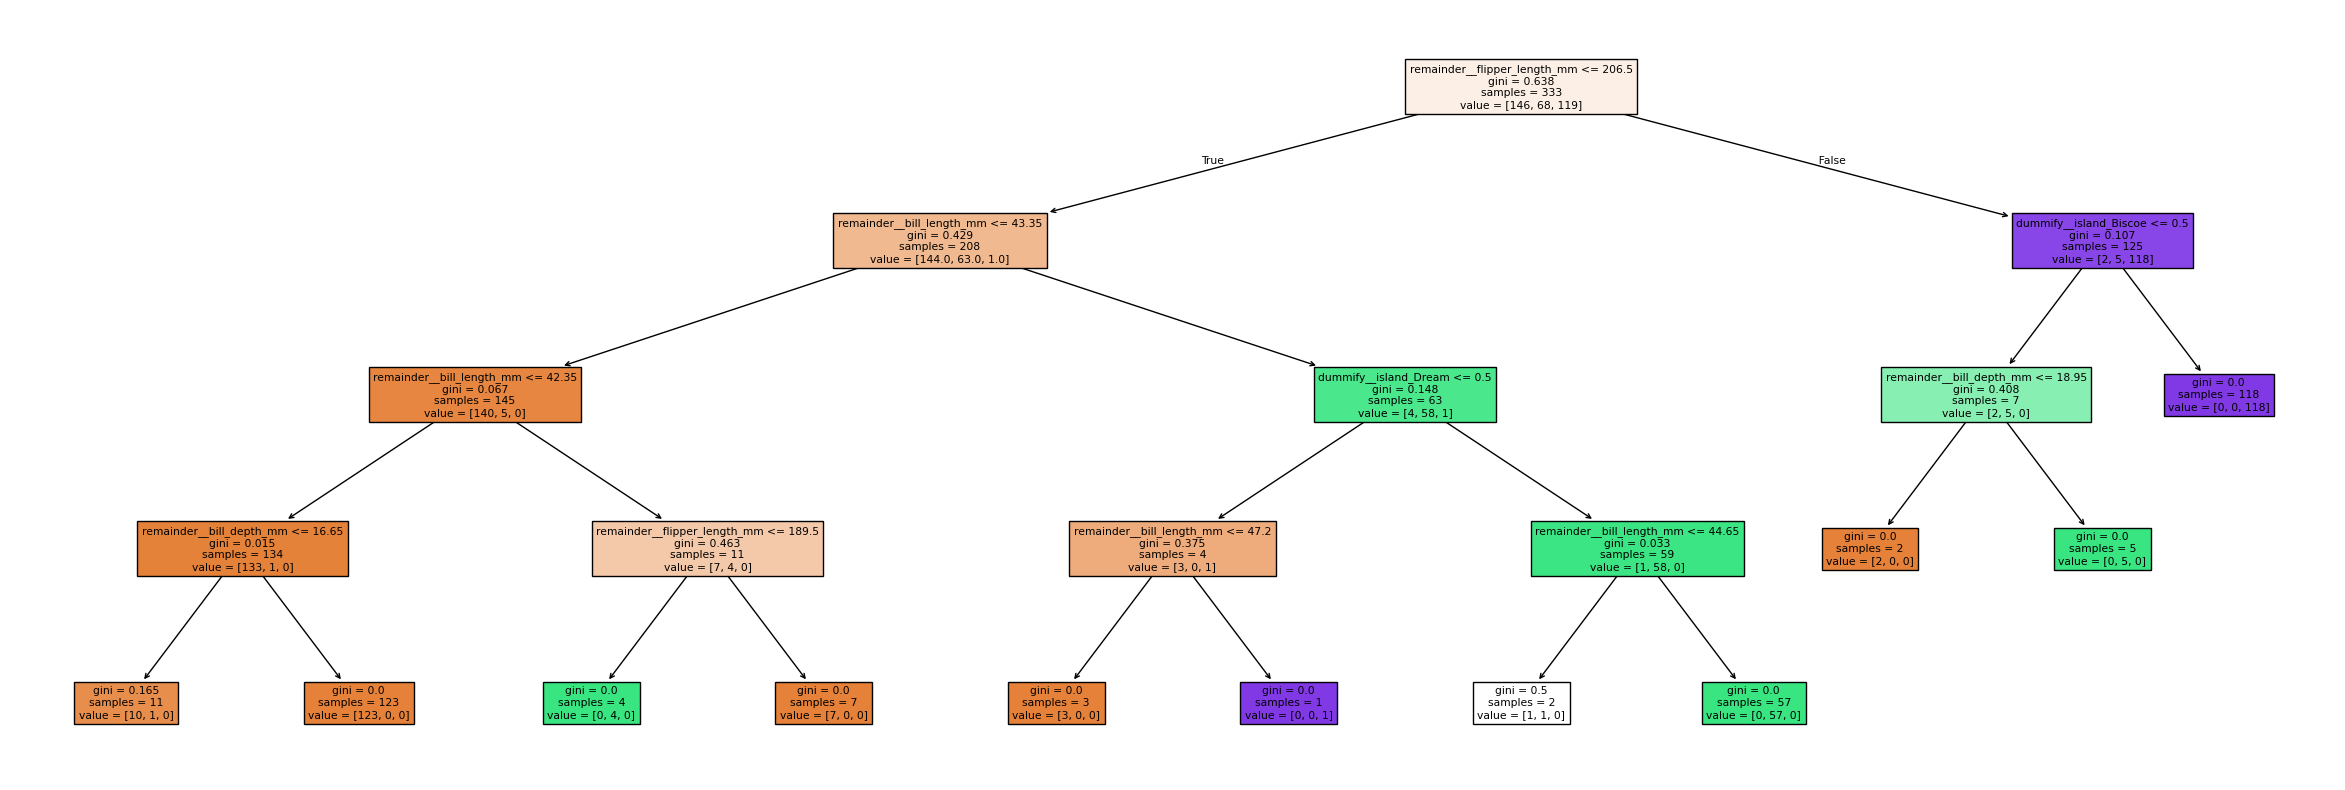

In [125]:
dt_pipeline2 = Pipeline(
  [("dummify", ct_dummify),
  ("decision_tree", DecisionTreeClassifier(max_depth=4))]
)

dt_pipeline2.fit(X=X, y=y)

# Access the Decision Tree estimator by its name in the pipeline
decision_tree_estimator = dt_pipeline2.named_steps['decision_tree']

feat_names = dt_pipeline2.named_steps["dummify"].get_feature_names_out(
    input_features=getattr(X, "columns", None)
)


# Plot the decision tree
plt.figure(figsize=(30,10))
plot_tree(decision_tree_estimator, feature_names=feat_names, filled = True)

In [127]:
#predict y values with cross validation
y_dt2_pred = cross_val_predict(dt_pipeline2, X, y, cv=cv)

In [131]:
#overall accuracy and confusion matrix
accuracy_dt2 = cross_val_score(dt_pipeline2, X, y,
                            cv=cv, scoring="accuracy")

accuracy_dt2.mean(), confusion_matrix(y, y_dt2_pred)

(np.float64(0.972998643147897),
 array([[143,   2,   1],
        [  3,  65,   0],
        [  1,   0, 118]]))

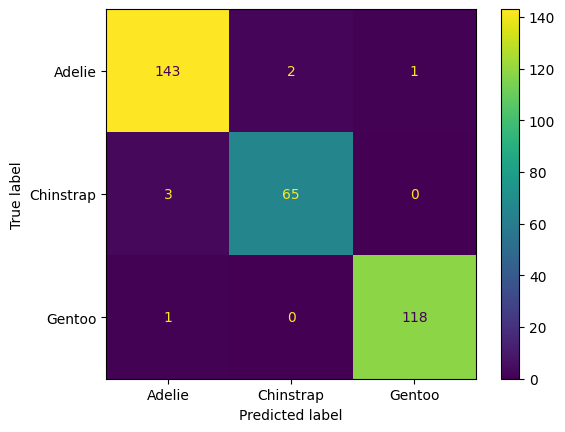

In [132]:
ConfusionMatrixDisplay.from_predictions(y, y_dt2_pred)

In [133]:
#precision, Recall, AUC, and F1-score for Adelie species
precision_dt2 = cross_val_score(dt_pipeline2, X, is_Adelie,
                cv=cv, scoring="precision").mean()

recall_dt2 = cross_val_score(dt_pipeline2, X, is_Adelie,
                cv=cv, scoring="recall").mean()

auc_dt2 = cross_val_score(dt_pipeline2, X, is_Adelie,
                cv=cv, scoring="roc_auc").mean()

f1score_dt2 = cross_val_score(dt_pipeline2, X, is_Adelie,
                            cv=cv, scoring="f1").mean()


precision_dt2, recall_dt2, auc_dt2, f1score_dt2

(np.float64(0.9808333333333333),
 np.float64(0.9793103448275862),
 np.float64(0.9859273066169619),
 np.float64(0.9826798518942536))

In [134]:
#precision, Recall, AUC, and F1-score for Gentoo species
precision_dt2 = cross_val_score(dt_pipeline2, X, is_Gentoo,
                cv=cv, scoring="precision").mean()

recall_dt2 = cross_val_score(dt_pipeline2, X, is_Gentoo,
                cv=cv, scoring="recall").mean()

auc_dt2 = cross_val_score(dt_pipeline2, X, is_Gentoo,
                cv=cv, scoring="roc_auc").mean()

f1score_dt2 = cross_val_score(dt_pipeline2, X, is_Gentoo,
                            cv=cv, scoring="f1").mean()


precision_dt2, recall_dt2, auc_dt2, f1score_dt2

(np.float64(0.992),
 np.float64(0.9916666666666668),
 np.float64(0.993452380952381),
 np.float64(0.9916630481980026))

In [135]:
#precision, Recall, AUC, and F1-score for Chinstrap species
precision_dt2 = cross_val_score(dt_pipeline2, X, is_Chinstrap,
                cv=cv, scoring="precision").mean()

recall_dt2 = cross_val_score(dt_pipeline2, X, is_Chinstrap,
                cv=cv, scoring="recall").mean()

auc_dt2 = cross_val_score(dt_pipeline2, X, is_Chinstrap,
                cv=cv, scoring="roc_auc").mean()

f1score_dt2 = cross_val_score(dt_pipeline2, X, is_Chinstrap,
                            cv=cv, scoring="f1").mean()


precision_dt2, recall_dt2, auc_dt2, f1score_dt2

(np.float64(0.9350000000000002),
 np.float64(0.9692307692307691),
 np.float64(0.9789550072568941),
 np.float64(0.9625925925925927))